In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from matplotlib.collections import PatchCollection
from matplotlib.markers import MarkerStyle
from matplotlib.path import Path
import btrack, numpy as np, pandas as pd
from btrack.constants import BayesianUpdates
from scipy.stats import zscore
from scipy.signal import savgol_filter

from scipy.stats import binned_statistic_2d
from scipy.signal import savgol_filter

import anndata as an
import scanpy as sc
from collections import Counter
from matplotlib.patches import Patch
import warnings

# tracking algs
import trackpy as tp

Notebook to predict cell cycle phases for individual cells from FUCCI time-series imaging data
* 4 conditions (N wells/replicates): Control (3), mmMYOD1 (2), siPRRX1 (2), HYB (3)

# Load in data

In [2]:
%%time
dpath = "/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/regionprops/"
file_list = glob.glob(f"{dpath}*_*_*.csv") # exclude the test image

df_list = []

for fpath in file_list:
    basename = os.path.basename(fpath).replace(".csv", "")
    stage, condition, scene, _ = basename.split("_")
    
    df = pd.read_csv(fpath)
    df['basename'] = basename
    df['stage'] = int(stage)
    df['condition'] = condition
    df['scene'] = scene
    
    print(f"\t{basename} {df.shape=}")

    df_list.append(df)


df = pd.concat(df_list)
print(f"{df.shape=}")

df['cell_id'] = df['basename'] + "_label" + df['label'].astype(str)

# shift stage 2 times to follow after stage 1
max_time_stage1 = df.loc[df["stage"] == 1, "time"].max()
df["time_shifted"] = df["time"] + (
    (df["stage"] == 2) * (max_time_stage1 + 1)
)

df.head()

	02_siPRRX1_B3_props df.shape=(188240, 49)
	01_mmMYOD1_D4_props df.shape=(35964, 49)
	01_control_D2_props df.shape=(31271, 49)
	01_hybrid_C3_props df.shape=(49123, 49)
	01_mmMYOD1_D3_props df.shape=(33663, 49)
	02_hybrid_C6_props df.shape=(123894, 49)
	02_hybrid_C4_props df.shape=(145648, 49)
	01_hybrid_C4_props df.shape=(64240, 49)
	02_mmMYOD1_D4_props df.shape=(72217, 49)
	02_siPRRX1_B4_props df.shape=(198826, 49)
	02_hybrid_C3_props df.shape=(133759, 49)
	01_hybrid_C6_props df.shape=(57297, 49)
	01_control_C2_props df.shape=(39967, 49)
	02_mmMYOD1_D3_props df.shape=(68484, 49)
	01_siPRRX1_B4_props df.shape=(80394, 49)
	02_control_C2_props df.shape=(94187, 49)
	01_siPRRX1_B3_props df.shape=(70595, 49)
	01_control_B2_props df.shape=(40213, 49)
	02_control_D2_props df.shape=(65965, 49)
	02_control_B2_props df.shape=(91039, 49)
df.shape=(1684986, 49)
CPU times: user 11.3 s, sys: 1.43 s, total: 12.7 s
Wall time: 14.6 s


,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox_area,centroid-0,centroid-1,eccentricity,...,mKate_sum,time,seg_channel_idx,seg_channel_name,basename,stage,condition,scene,cell_id,time_shifted
0,1,139.0,770,366,786,378,192.0,777.402878,371.733813,0.787459,...,29.239852,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label1,67
1,2,92.0,513,2953,524,2964,121.0,517.945652,2957.891304,0.204520,...,11.038021,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label2,67
2,3,131.0,2553,722,2566,735,169.0,2558.908397,727.664122,0.528127,...,16.582590,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label3,67
3,4,638.0,2205,1117,2234,1148,899.0,2219.070533,1131.733542,0.746750,...,135.223725,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label4,67
4,5,146.0,702,806,719,818,204.0,710.260274,811.657534,0.793181,...,30.855447,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label5,67


# Visualize reporters

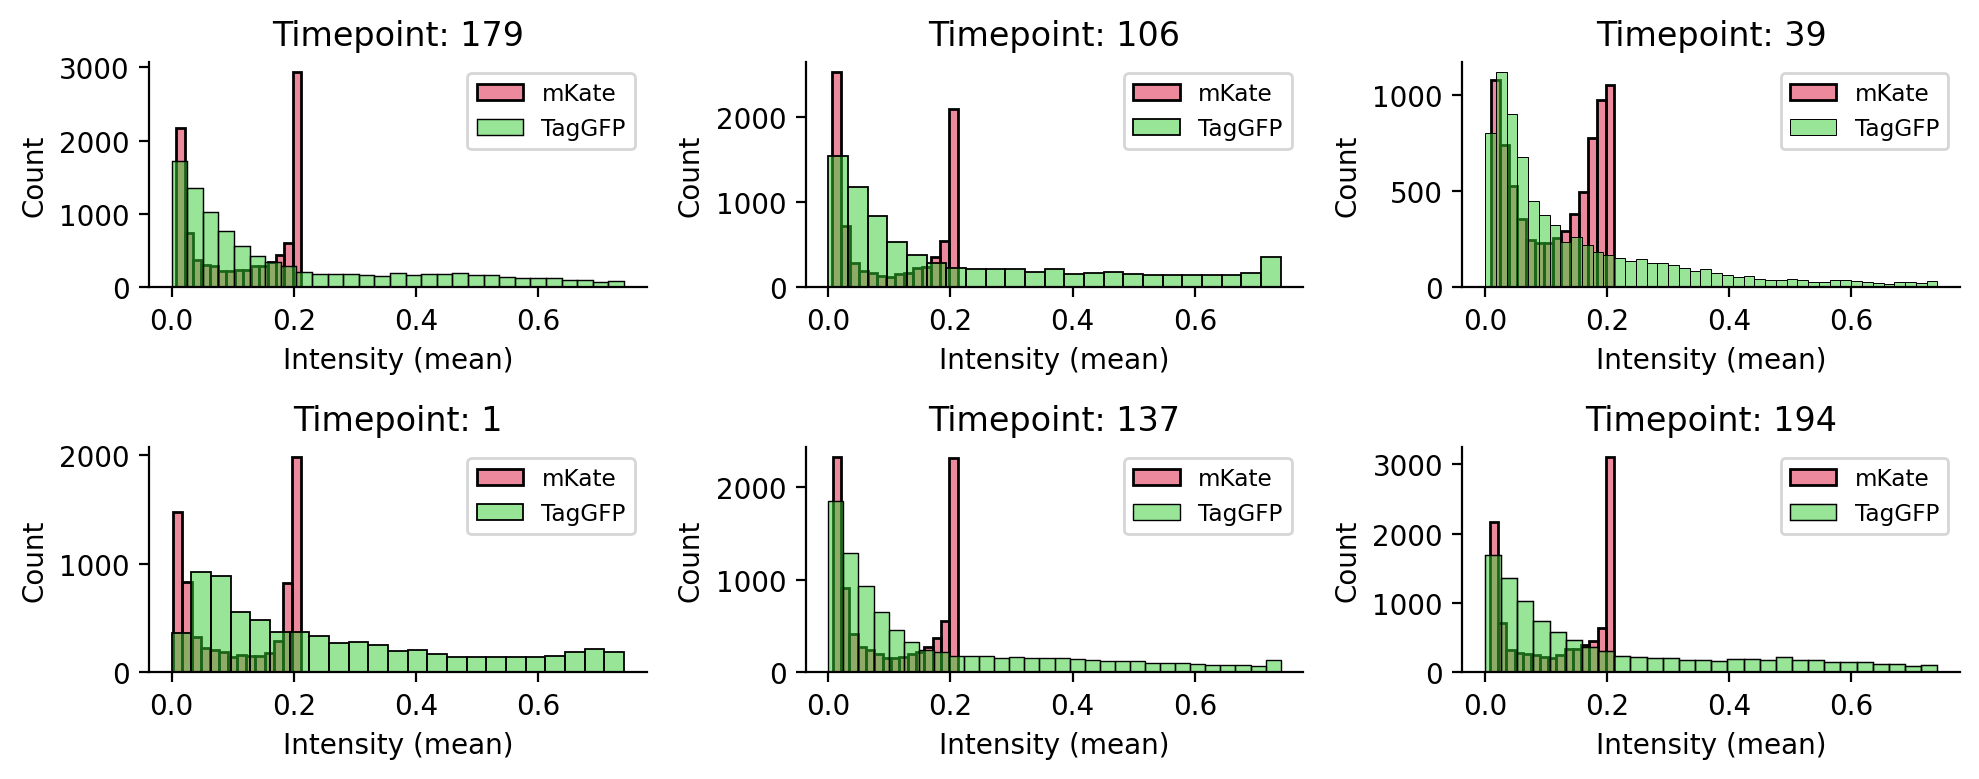

In [4]:
# pick 6 random time points
timepoints = np.random.choice(df["time_shifted"].unique(), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(10, 4), dpi=200)

for ax, time in zip(axes.flatten(), timepoints):
    subset = df[df['time_shifted'] == time]

    sns.histplot(
        data=subset,
        x='mKate_mean',
        color='crimson',
        alpha=0.5,
        label='mKate',
        ax=ax
    )

    sns.histplot(
        data=subset,
        x='TaGFP_mean',
        color='limegreen',
        alpha=0.5,
        label='TagGFP',
        ax=ax
    )

    ax.set_title(f"Timepoint: {time}")
    ax.set_xlabel("Intensity (mean)")
    ax.set_ylabel("Count")
    ax.legend(fontsize='small')

sns.despine()
plt.tight_layout()
plt.show()

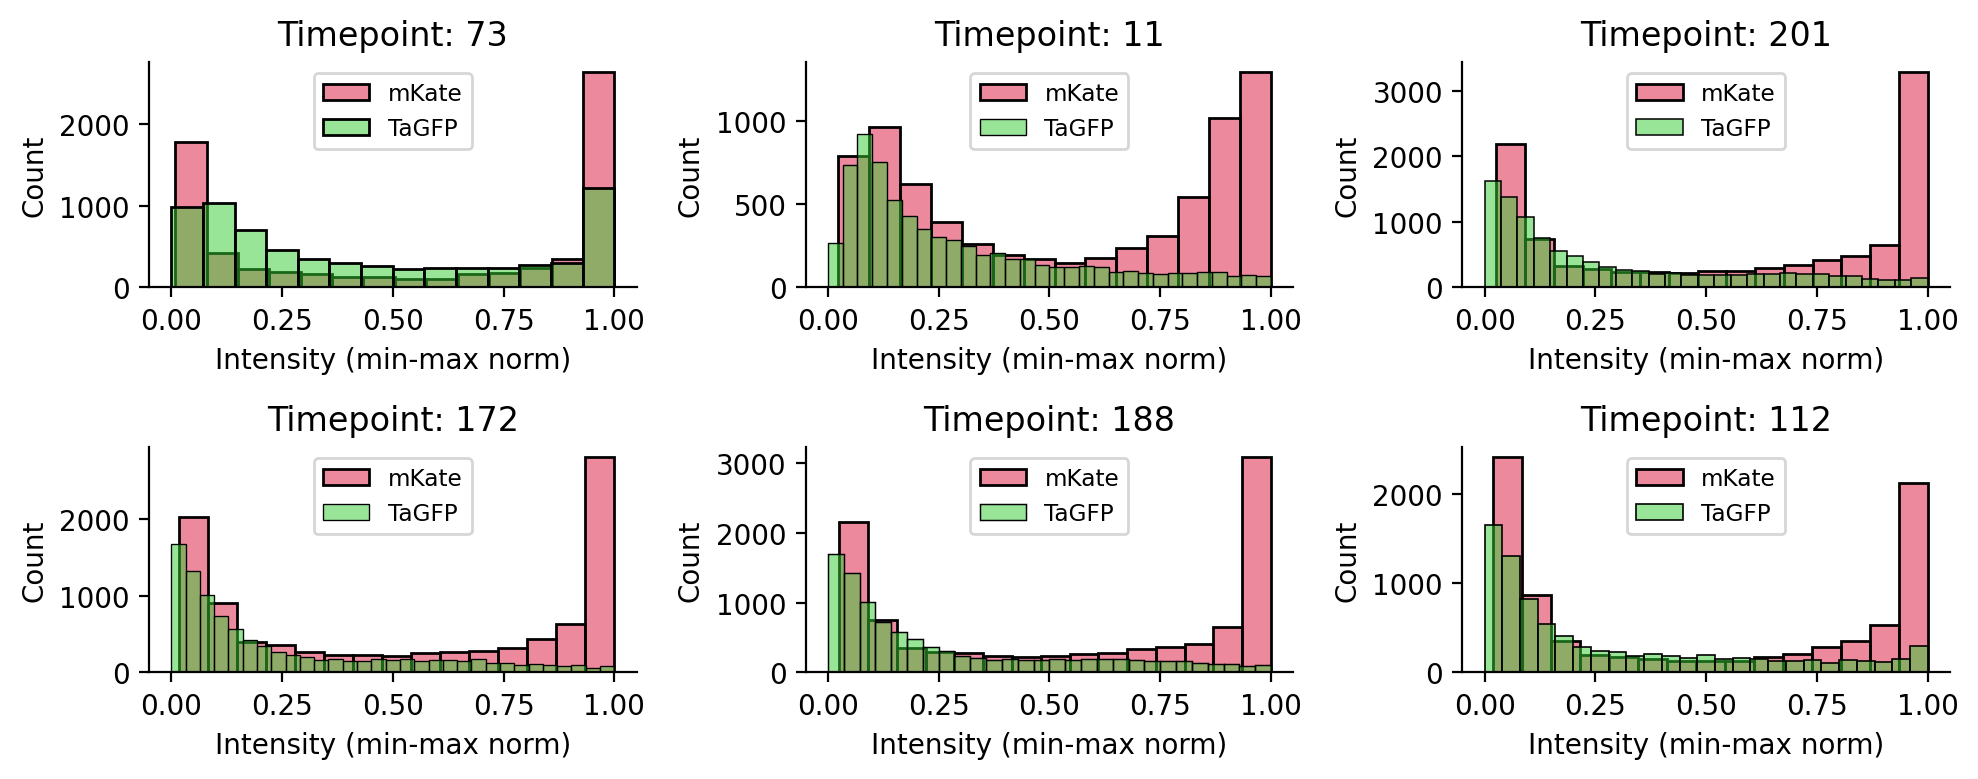

In [5]:
# Simple normalization (min-max)
df['TaGFP_norm'] = (df['TaGFP_mean'] - df['TaGFP_mean'].min()) / (df['TaGFP_mean'].max() - df['TaGFP_mean'].min())
df['mKate_norm'] = (df['mKate_mean'] - df['mKate_mean'].min()) / (df['mKate_mean'].max() - df['mKate_mean'].min())

# pick 6 random time points
timepoints = np.random.choice(df["time_shifted"].unique(), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(10, 4), dpi=200)
# fig, axes = plt.subplots(3, 2, figsize=(7, 6), dpi=200)

for ax, time in zip(axes.flatten(), timepoints):
    subset = df[df['time_shifted'] == time]

    sns.histplot(
        data=subset,
        x='mKate_norm',
        color='crimson',
        alpha=0.5,
        label='mKate',
        ax=ax
    )

    sns.histplot(
        data=subset,
        x='TaGFP_norm',
        color='limegreen',
        alpha=0.5,
        label='TaGFP',
        ax=ax
    )

    ax.set_title(f"Timepoint: {time}")
    ax.set_xlabel("Intensity (min-max norm)")
    ax.set_ylabel("Count")
    ax.legend(fontsize='small')

sns.despine()
plt.tight_layout()
plt.show()

# Track cells

In [6]:
%%time
### --- Tracking by stage ---
# Rename columns for trackpy
pdf = df.rename(columns={
    "time": "frame",
    "centroid_x_px": "x",
    "centroid_y_px": "y"
}).copy()

# Store all per-(cond,scene,stage) tracking results in a list
all_track_dfs = []

for (cond, scene, stage), g in pdf.groupby(["condition", "scene", "stage"]):
    print(f"Tracking: {(cond, scene, stage)}")
    g_sorted = g.sort_values("frame")
    
    # Run tracking
    linked = tp.link_df(
        g_sorted,
        search_range=55,        # adjust as needed
        memory=5,
        adaptive_stop=True
    )
    
    # Add context columns
    linked["condition"] = cond
    linked["scene"] = scene
    linked["stage"] = stage
    
    # Optionally filter out short tracks (e.g., less than 50 frames)
    linked = tp.filter_stubs(linked, threshold=10)
    
    print(f"\tlinked.shape: {linked.shape}")
    
    all_track_dfs.append(linked)

# Combine all per-stage results
all_traj = pd.concat(all_track_dfs, ignore_index=True)
print(f"All tracked data shape: {all_traj.shape}")

Frame 136: 1690 trajectories present.
	linked.shape: (194021, 54)
All tracked data shape: (1633220, 54)
CPU times: user 51.2 s, sys: 3.67 s, total: 54.9 s
Wall time: 1min


In [7]:
all_traj['particle_id'] = all_traj['stage'].astype(str) + '_' + all_traj['condition'] + '_' + all_traj['scene'] + '_' + all_traj['particle'].astype(str)

columns_to_keep = [
    'condition', 'scene', 'stage', 'particle', 'particle_id', 'frame', 'time_shifted',
    'filled_area', 'Cy5_mean', 'TaGFP_mean', 'mKate_mean', 'x', 'y',
]

all_traj = all_traj[columns_to_keep]

all_traj.head()

,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,0.206251,33.529412,156.867647
1,control,B2,1,2,1_control_B2_2,0,0,107.0,0.094927,0.234181,0.180446,232.588785,2579.112150
2,control,B2,1,3,1_control_B2_3,0,0,118.0,0.037478,0.136275,0.193143,616.525424,551.245763
3,control,B2,1,4,1_control_B2_4,0,0,157.0,0.040521,0.247596,0.201448,1693.929936,2509.847134
4,control,B2,1,5,1_control_B2_5,0,0,86.0,0.107119,0.047916,0.010504,2243.581395,2229.174419


In [8]:
print(all_traj.shape)

(1633220, 13)


# Filter trajectories

In [9]:
# calculate total trajectory length per cell
all_traj['path_length'] = all_traj.groupby('particle_id')['frame'].transform(lambda x: x.nunique())

all_traj.groupby('condition')['path_length'].describe()

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
control,352727.0,90.757302,39.345742,10.0,67.0,77.0,137.0,137.0
hybrid,555376.0,79.582240,39.261481,10.0,50.0,67.0,122.0,137.0
mmMYOD1,201974.0,88.038550,38.563494,10.0,66.0,70.0,135.0,137.0
siPRRX1,523143.0,80.494096,38.007753,10.0,55.0,67.0,119.0,137.0


In [10]:
tdf = all_traj.copy()
print(f"N cells: {tdf['particle_id'].nunique()}")

min_path_length = 50

# remove short trajectories
tdf = tdf[tdf['path_length'] >= min_path_length]
print(f"N cells with at least 50 frames: {tdf['particle_id'].nunique()}\n")

# assess trajectory gaps
tdf = tdf.sort_values(['particle_id', 'frame'])

tdf['frame_diff'] = tdf.groupby('particle_id')['frame'].diff()

# Find gaps (diff > 1)
tdf['gap_length'] = tdf['frame_diff'] - 1
tdf['gap_length'] = tdf['gap_length'].where(tdf['gap_length'] > 0, 0)  # set negative/0 diffs to 0

gap_info = tdf.groupby('particle_id')['gap_length'].agg([
    ('has_gap', lambda x: x.gt(0).any()),
    ('max_gap_length', 'max')
]).reset_index()

# Merge flag and gap info back to the original dataframe
tdf = tdf.merge(gap_info, on='particle_id')
tdf = tdf.drop(columns=['frame_diff'])

print(f"{tdf.drop_duplicates('particle_id')['has_gap'].value_counts()}\n")

tdf.drop_duplicates('particle_id').groupby('condition')['max_gap_length'].describe()

N cells: 27824
N cells with at least 50 frames: 15068

has_gap
False    8941
True     6127
Name: count, dtype: int64



,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
control,3366.0,0.624777,1.321116,0.0,0.0,0.0,0.0,5.0
hybrid,4908.0,1.305420,1.655664,0.0,0.0,0.0,2.0,5.0
mmMYOD1,1957.0,0.761369,1.405794,0.0,0.0,0.0,1.0,5.0
siPRRX1,4837.0,1.330784,1.703688,0.0,0.0,0.0,3.0,5.0


# Normalize reporters

In [11]:
### ALL RANDOM
# test_size = 500
# sampled_cells = np.random.choice(tdf['particle_id'].unique(), size=test_size, replace=False)

# test_df = tdf[tdf['particle_id'].isin(sampled_cells)].reset_index(drop=True)
# print(f"N cells: {test_df['particle_id'].nunique()}")

# ### RANDOM PER CONDITION
# sampled_cells = (
#     tdf.groupby('condition')['particle_id']
#     .apply(lambda x: np.random.choice(x.unique(), size=200, replace=False))
#     .explode()
#     .tolist()
# )

# test_df = tdf[tdf['particle_id'].isin(sampled_cells)].reset_index(drop=True)
# print(f"N cells: {test_df['particle_id'].nunique()}")

## ALL CELLS
test_df = tdf.copy()
print(f"N cells: {test_df['particle_id'].nunique()}")

mKate_global_max = test_df['mKate_mean'].max()
TaGFP_global_max = test_df['TaGFP_mean'].max()
print(f"mKate global max: {mKate_global_max}")
print(f"TaGFP global max: {TaGFP_global_max}")

# Global normalization for each reporter
test_df['TaGFP_norm'] = (test_df['TaGFP_mean'] - test_df['TaGFP_mean'].min()) / (test_df['TaGFP_mean'].max() - test_df['TaGFP_mean'].min())
test_df['mKate_norm'] = (test_df['mKate_mean'] - test_df['mKate_mean'].min()) / (test_df['mKate_mean'].max() - test_df['mKate_mean'].min())
test_df['Cy5_norm'] = (test_df['Cy5_mean'] - test_df['Cy5_mean'].min()) / (test_df['Cy5_mean'].max() - test_df['Cy5_mean'].min())

print(test_df.shape)
test_df.head()

N cells: 15068
mKate global max: 0.2119494117647059
TaGFP global max: 0.7408690196078433
(1300948, 20)


,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y,path_length,gap_length,has_gap,max_gap_length,TaGFP_norm,mKate_norm,Cy5_norm
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,0.206251,33.529412,156.867647,67,0.0,False,0.0,0.551797,0.972797,0.060081
1,control,B2,1,0,1_control_B2_0,1,1,143.0,0.149553,0.394926,0.205844,32.937063,157.265734,67,0.0,False,0.0,0.533058,0.970855,0.176731
2,control,B2,1,0,1_control_B2_0,2,2,153.0,0.252953,0.375882,0.202407,34.091503,159.078431,67,0.0,False,0.0,0.507353,0.954446,0.314127
3,control,B2,1,0,1_control_B2_0,3,3,156.0,0.374112,0.369431,0.197891,33.737179,160.628205,67,0.0,False,0.0,0.498645,0.932890,0.475121
4,control,B2,1,0,1_control_B2_0,4,4,158.0,0.486338,0.368193,0.197863,34.177215,161.974684,67,0.0,False,0.0,0.496974,0.932758,0.624245


# Cell counts

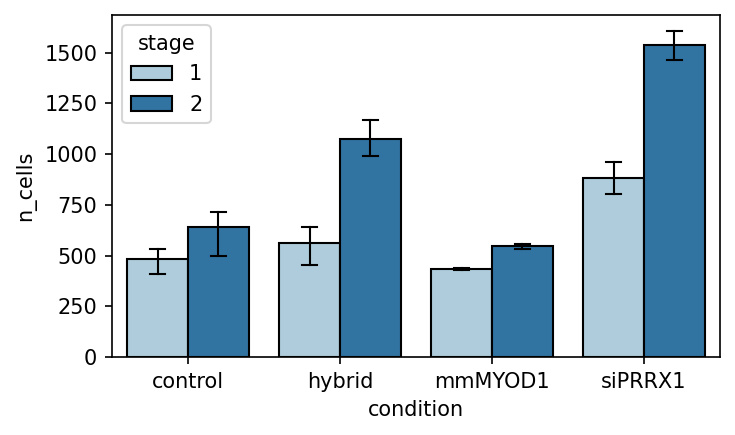

In [12]:
cell_counts = (
    test_df.groupby(['condition', 'scene', 'stage'])['particle_id']
    .nunique()
    .reset_index(name='n_cells')
)

plt.rcParams['figure.dpi'] = 150
fig, ax = plt.subplots(figsize=(5, 3))

sns.barplot(
    cell_counts,
    x='condition',
    y='n_cells',
    hue='stage',
    palette='Paired',
    ec='k',
    linewidth=1,
    capsize=0.2,
    err_kws={'color': 'k', 'lw': 1},
)

plt.tight_layout()
plt.show()

# Flag noisy cells

In [13]:
%%time

red = 'mKate_norm'
green = 'TaGFP_norm'
jump_thresh = 0.5
max_allowed_jumps = 2

df = test_df.copy()

# --- Compute per-row differences, grouped by cell ---
df['red_diff'] = df.groupby('particle_id')[red].diff().abs()
df['green_diff'] = df.groupby('particle_id')[green].diff().abs()

# --- Flag "big jumps" ---
df['red_big_jump'] = df['red_diff'] > jump_thresh
df['green_big_jump'] = df['green_diff'] > jump_thresh

# --- Aggregate per-cell (particle_id): count of big jumps ---
jump_counts = (
    df.groupby('particle_id')[['red_big_jump', 'green_big_jump']].sum()
    .rename(columns={'red_big_jump': 'red_big_jump_count', 'green_big_jump': 'green_big_jump_count'})
)

# --- Flag noisy cells at the cell (particle) level ---
jump_counts['noisy'] = (jump_counts['red_big_jump_count'] > max_allowed_jumps) | \
                       (jump_counts['green_big_jump_count'] > max_allowed_jumps)

# --- Merge/noisy to df, then broadcast to all rows for each cell ---
noisy_map = jump_counts['noisy']
df['noisy'] = df['particle_id'].map(noisy_map)

# Optional: Clean up helper cols
df.drop(['red_diff', 'green_diff', 'red_big_jump', 'green_big_jump'], axis=1, inplace=True)
df.head()

CPU times: user 1.13 s, sys: 240 ms, total: 1.37 s
Wall time: 1.39 s


,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,x,y,path_length,gap_length,has_gap,max_gap_length,TaGFP_norm,mKate_norm,Cy5_norm,noisy
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,...,33.529412,156.867647,67,0.0,False,0.0,0.551797,0.972797,0.060081,False
1,control,B2,1,0,1_control_B2_0,1,1,143.0,0.149553,0.394926,...,32.937063,157.265734,67,0.0,False,0.0,0.533058,0.970855,0.176731,False
2,control,B2,1,0,1_control_B2_0,2,2,153.0,0.252953,0.375882,...,34.091503,159.078431,67,0.0,False,0.0,0.507353,0.954446,0.314127,False
3,control,B2,1,0,1_control_B2_0,3,3,156.0,0.374112,0.369431,...,33.737179,160.628205,67,0.0,False,0.0,0.498645,0.932890,0.475121,False
4,control,B2,1,0,1_control_B2_0,4,4,158.0,0.486338,0.368193,...,34.177215,161.974684,67,0.0,False,0.0,0.496974,0.932758,0.624245,False


## Visualize

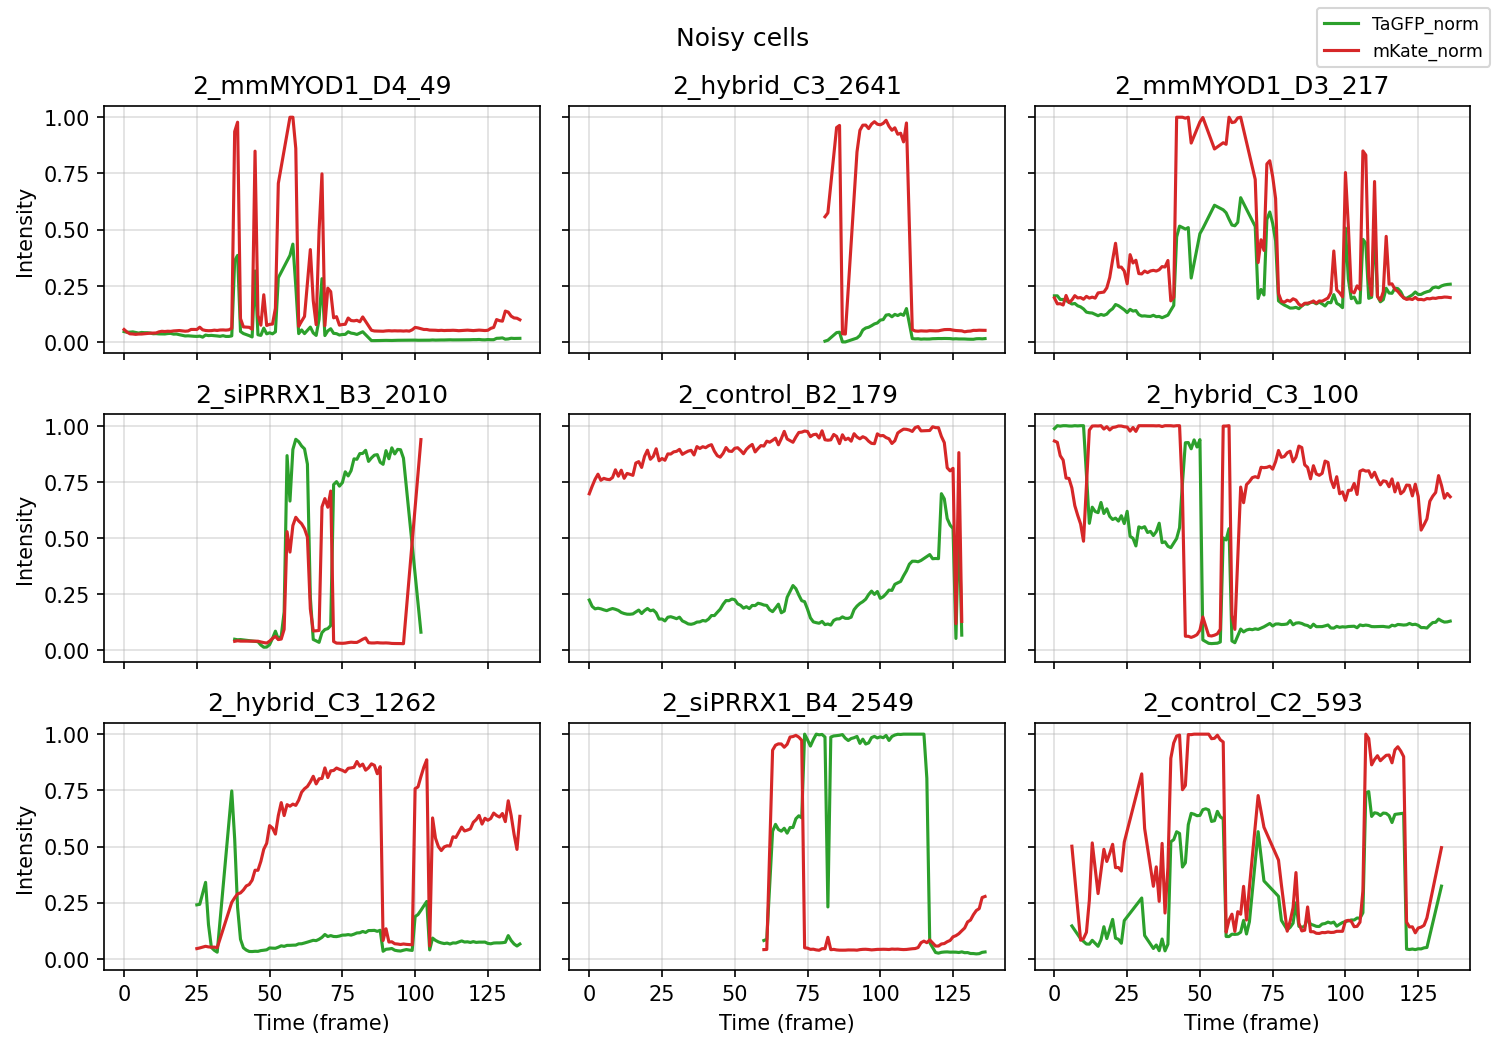

In [14]:
### visualize noisy cells

tmp = df[df['noisy']]
         
noisy_cells = np.random.choice(tmp['particle_id'].unique(), size=9, replace=False)
# noisy_cells = tmp[tmp['noisy']]['particle_id'].unique()

n_cols = 3
n_rows = int(np.ceil(len(noisy_cells) / n_cols))


fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 7), sharex=True, sharey=True, dpi=150)
axes = axes.flatten()

for idx, cell_id in enumerate(noisy_cells):
    ax = axes[idx]
    cdf = df[df['particle_id'] == cell_id].sort_values('frame')
    
    ax.plot(cdf['frame'], cdf['TaGFP_norm'], label='TaGFP_norm', color='tab:green')
    ax.plot(cdf['frame'], cdf['mKate_norm'], label='mKate_norm', color='tab:red')
    
    ax.set_title(f'{cell_id}')
    ax.grid(True, alpha=0.4)
    ax.set_xlabel('Time (frame)' if idx // n_cols == n_rows - 1 else '')
    ax.set_ylabel('Intensity' if idx % n_cols == 0 else '')

for ax in axes[len(noisy_cells):]:
    ax.set_visible(False)
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize='small')

plt.suptitle("Noisy cells")
plt.tight_layout()
plt.show()

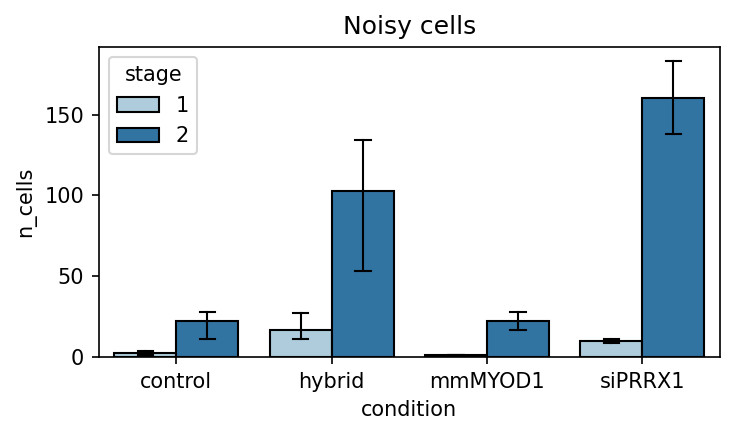

In [15]:
cell_counts = (
    tmp.groupby(['condition', 'scene', 'stage'])['particle_id']
    .nunique()
    .reset_index(name='n_cells')
)

plt.rcParams['figure.dpi'] = 150
fig, ax = plt.subplots(figsize=(5, 3))

sns.barplot(
    cell_counts,
    x='condition',
    y='n_cells',
    hue='stage',
    palette='Paired',
    ec='k',
    linewidth=1,
    capsize=0.2,
    err_kws={'color': 'k', 'lw': 1},
)

plt.title("Noisy cells")
plt.tight_layout()
plt.show()

N cells after dropping noisy cells: 14249


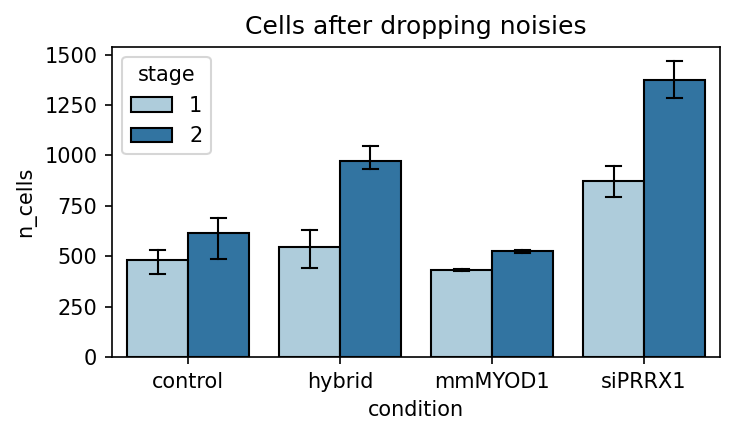

In [16]:
df = df[~df['noisy']]

print(f"N cells after dropping noisy cells: {df['particle_id'].nunique()}")

cell_counts = (
    df.groupby(['condition', 'scene', 'stage'])['particle_id']
    .nunique()
    .reset_index(name='n_cells')
)

plt.rcParams['figure.dpi'] = 150
fig, ax = plt.subplots(figsize=(5, 3))

sns.barplot(
    cell_counts,
    x='condition',
    y='n_cells',
    hue='stage',
    palette='Paired',
    ec='k',
    linewidth=1,
    capsize=0.2,
    err_kws={'color': 'k', 'lw': 1},
)

plt.title("Cells after dropping noisies")
plt.tight_layout()
plt.show()

# Smooth signal (savgol filter)

/tmp/ipykernel_784662/3708122119.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('particle_id', group_keys=False).apply(


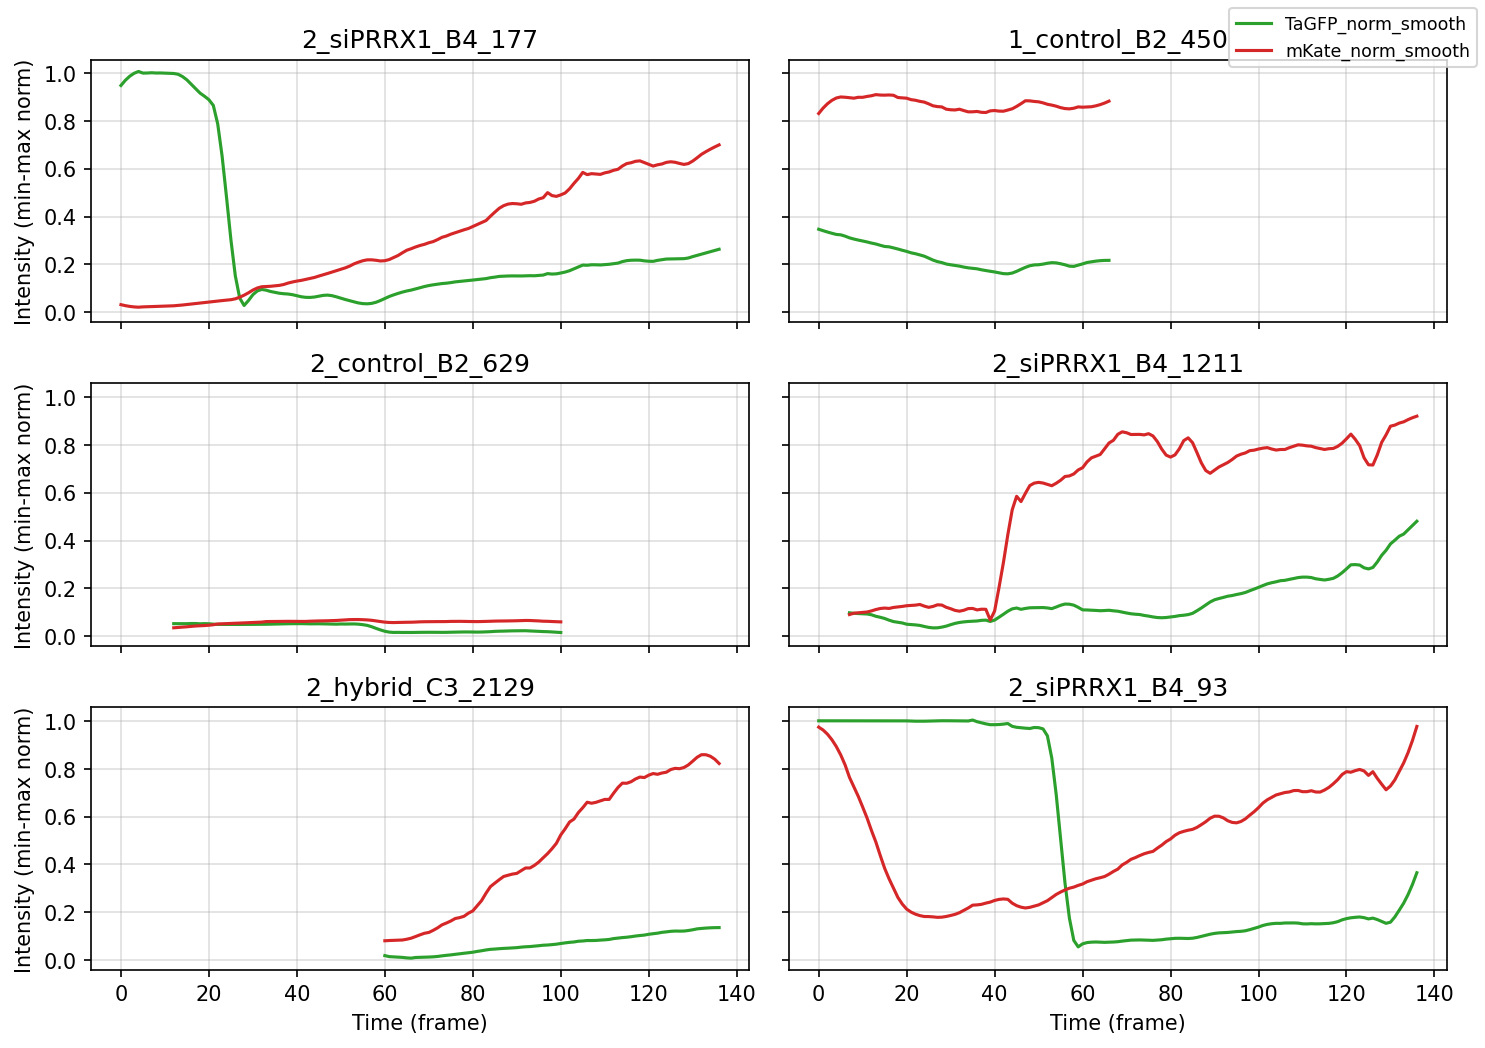

In [17]:
def smooth_reporters_group(g, red_col='mKate_norm', green_col='TaGFP_norm', nuc_col='Cy5_norm', window_length=7, polyorder=2):
    g = g.copy()  # Don't modify in-place.
    n = len(g)
    # Must have enough points for filter
    good_len = min(n, window_length if n % 2 == 1 else window_length - 1)
    if good_len < 3:
        g[red_col + '_smooth'] = g[red_col]
        g[green_col + '_smooth'] = g[green_col]
        g[nuc_col + '_smooth'] = g[nuc_col]
    else:
        g = g.sort_values('frame')  # ensure frame order
        g[red_col + '_smooth'] = savgol_filter(g[red_col], window_length=good_len, polyorder=min(polyorder, good_len-1))
        g[green_col + '_smooth'] = savgol_filter(g[green_col], window_length=good_len, polyorder=min(polyorder, good_len-1))
        g[nuc_col + '_smooth'] = savgol_filter(g[nuc_col], window_length=good_len, polyorder=min(polyorder, good_len-1))
    return g

# Use groupby.apply for speed and auto-concatenation
df = df.groupby('particle_id', group_keys=False).apply(
    smooth_reporters_group, 
    red_col='mKate_norm', 
    green_col='TaGFP_norm', 
    nuc_col='Cy5_norm',
    window_length=9, 
    polyorder=2
)

sampled_cells = np.random.choice(df['particle_id'].unique(), size=6, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True, sharey=True, dpi=150)

for idx, cell_id in enumerate(sampled_cells):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    
    cdf = df[df['particle_id'] == cell_id].sort_values('frame')
    
    ax.plot(cdf['frame'], cdf['TaGFP_norm_smooth'], label='TaGFP_norm_smooth', color='tab:green')
    ax.plot(cdf['frame'], cdf['mKate_norm_smooth'], label='mKate_norm_smooth', color='tab:red')
    # ax.plot(cdf['frame'], cdf['Cy5_norm_smooth'], label='Cy5_norm_smooth', color='tab:blue')
    
    ax.set_title(f'{cell_id}')
    ax.grid(True, alpha=0.4)
    if row == 2: 
        ax.set_xlabel('Time (frame)')
    else:
        ax.set_xlabel('')
    if col == 0:
        ax.set_ylabel('Intensity (min-max norm)')
    else:
        ax.set_ylabel('')
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

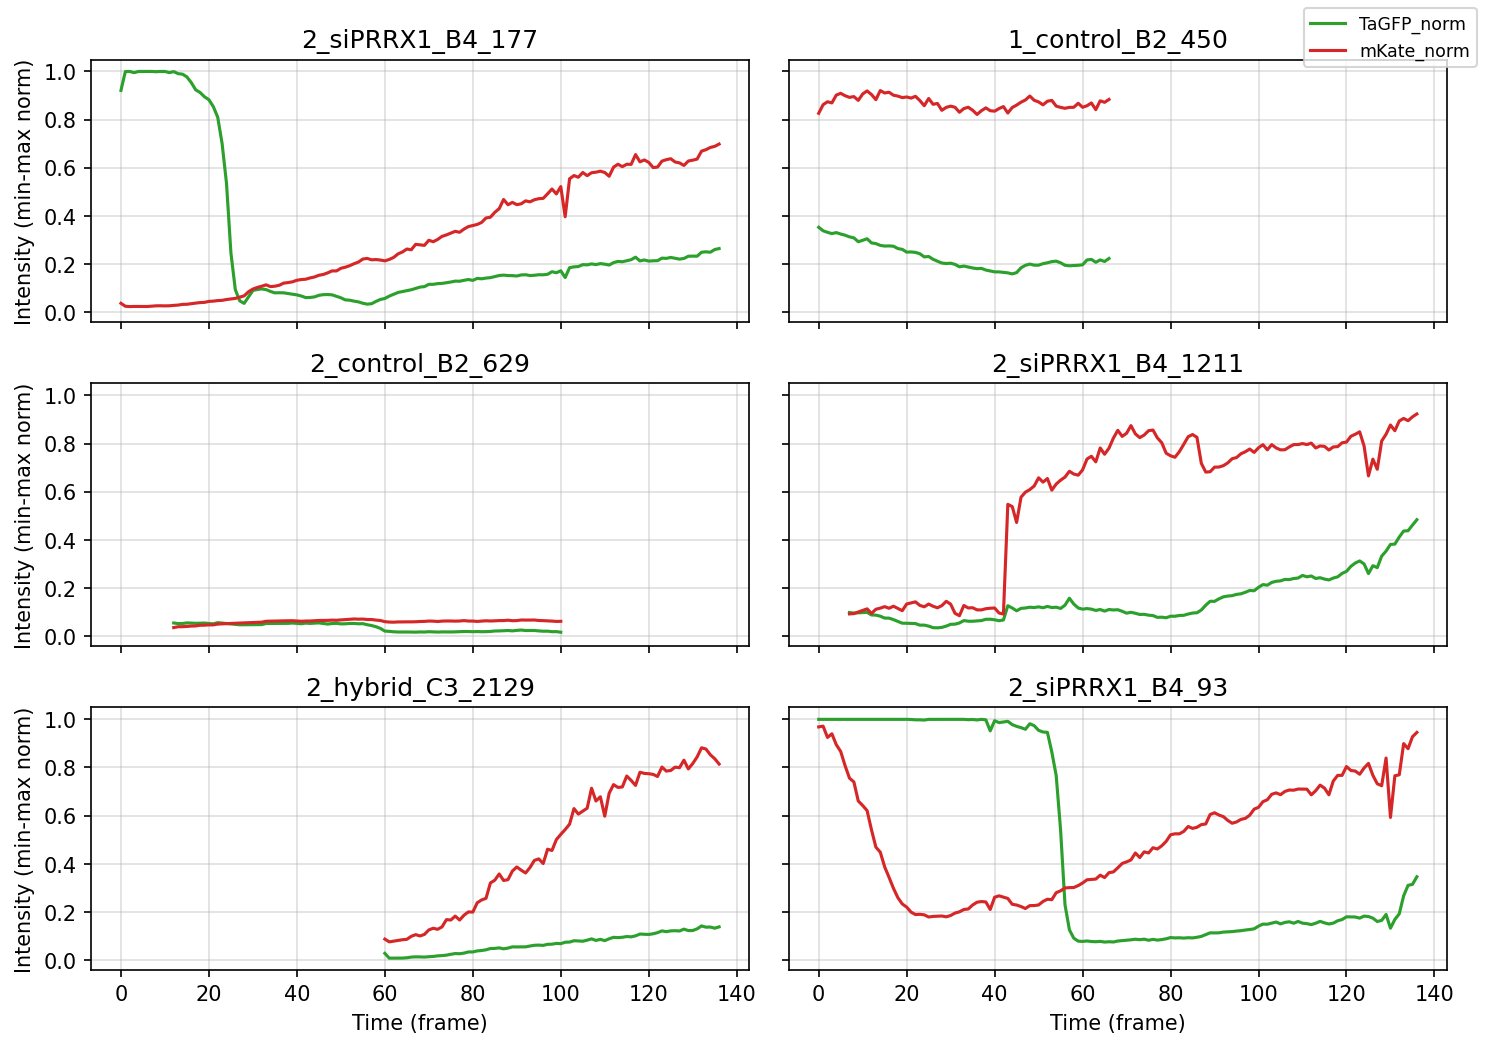

In [18]:
## Look at the unsmoothed signals
fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True, sharey=True)

for idx, cell_id in enumerate(sampled_cells):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    
    cdf = df[df['particle_id'] == cell_id].sort_values('frame')
    
    ax.plot(cdf['frame'], cdf['TaGFP_norm'], label='TaGFP_norm', color='tab:green')
    ax.plot(cdf['frame'], cdf['mKate_norm'], label='mKate_norm', color='tab:red')
    
    ax.set_title(f'{cell_id}')
    ax.grid(True, alpha=0.4)
    if row == 2: 
        ax.set_xlabel('Time (frame)')
    else:
        ax.set_xlabel('')
    if col == 0:
        ax.set_ylabel('Intensity (min-max norm)')
    else:
        ax.set_ylabel('')
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

# Phase assignment logic

In [19]:
# Suppress warnings related to chained assignment and infer_objects
warnings.filterwarnings('ignore', category=pd.errors.ChainedAssignmentError)
pd.set_option('future.no_silent_downcasting', True)

# --- Utility Functions ---

def rolling_mode_labels(labels, window):
    """
    Computes the rolling mode for a Series of labels.
    """
    half = window // 2
    out = []
    n = len(labels)
    labels_list = labels.tolist()
    
    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        seg = labels_list[lo:hi]
        
        if not seg:
            out.append(np.nan)
        else:
            out.append(Counter(seg).most_common(1)[0][0]) # gets the most frequent item
            
    return pd.Series(out, index=labels.index)

def fill_short_gaps(
    df_part, frame_col='frame', 
    cols_to_fill=['mKate_norm_smooth', 'TaGFP_norm_smooth', 'ratio'], 
    max_gap_fill=5, gap_neighborhood=3
):
    """
    Fills short gaps (NaNs) in specified columns by linear reindexing, 
    grouping NaN blocks, and filling with the mean of a surrounding neighborhood.
    """
    df_part = df_part.sort_values(frame_col).set_index(frame_col).copy()
    full_idx = np.arange(df_part.index.min(), df_part.index.max() + 1)
    df_full = df_part.reindex(full_idx)
    df_full.index.name = frame_col

    is_nan = df_full[cols_to_fill[0]].isna()
    # Identify contiguous NaN blocks
    nan_groups = (is_nan != is_nan.shift(1)).cumsum()[is_nan]
    
    for _, group_idx in nan_groups.groupby(nan_groups).groups.items():
        gap_frames = df_full.loc[group_idx].index.values
        gap_len = len(gap_frames)
        
        if gap_len <= max_gap_fill:
            gap_min, gap_max = gap_frames.min(), gap_frames.max()
            neigh_lo = gap_min - gap_neighborhood
            neigh_hi = gap_max + gap_neighborhood
            
            # Find indices in the neighborhood, excluding the gap itself
            neigh_idx = [
                f for f in range(neigh_lo, neigh_hi + 1)
                if (f in df_full.index) and (f < gap_min or f > gap_max)
            ]
            
            for col in cols_to_fill:
                neigh_vals = df_full.loc[neigh_idx, col].dropna()
                if len(neigh_vals) > 0:
                    # Fill the gap with the mean of the surrounding neighborhood
                    df_full.loc[gap_min:gap_max, col] = neigh_vals.mean()

    df_full = df_full.reset_index()
    # Back- and forward-fill remaining non-filled columns (e.g., IDs)
    for c in df_part.columns:
        if c not in cols_to_fill:
            df_full[c] = df_full[c].ffill().bfill().infer_objects(copy=False)
            
    return df_full

def _assign_block(arr, block_label, before_label, after_label, 
                  expr_mask, df, red_col, green_col, reporter_thresh):
    """Helper function to assign blocks of 'unassigned' phase labels based on context."""
    n_blocks = len(arr)
    i = 0
    while i < n_blocks:
        if arr[i] == 'unassigned':
            # Find the contiguous block of 'unassigned'
            block_start = i
            while (i + 1 < n_blocks) and (arr[i + 1] == 'unassigned'):
                i += 1
            block_end = i

            # Look for previous and next non-block labels
            prev = block_start - 1
            while prev >= 0 and arr[prev] == 'unassigned': prev -= 1
            prev_label = arr[prev] if prev >= 0 else None

            next_ = block_end + 1
            while next_ < n_blocks and arr[next_] == 'unassigned': next_ += 1
            next_label = arr[next_] if next_ < n_blocks else None

            # Check if any frame in the block is expressed
            block_expr = np.any(expr_mask[block_start:block_end + 1])

            # Standard edge/context logic + expression check
            if block_expr and (
                (prev_label == before_label and next_label == after_label) or
                (prev < 0 and next_label == after_label) or
                (prev_label == before_label and next_ >= n_blocks)
            ):
                for k in range(block_start, block_end + 1):
                    arr[k] = block_label
            # Move to the frame after the processed block
            i = block_end + 1
        else:
            i += 1
    return arr


def _assign_M_context_dynamics_and_fill(
    arr, df, red_col, green_col, m_win, min_switch, min_flank_block, max_m_len
):
    """
    Assigns 'M' phase by checking S/G2/M -> G1 context and marker dynamics, 
    and fills the remainder of the block.
    """
    # Calculate kinetic score: large drop in red AND large rise in green (M to G1)
    mkate_delta = df[red_col].diff().fillna(0).values
    tagfp_delta = df[green_col].diff().fillna(0).values
    n = len(arr)
    i = 0
    
    while i < n:
        if arr[i] == 'unassigned':
            block_start = i
            block_end = i
            while block_end + 1 < n and arr[block_end + 1] == 'unassigned':
                block_end += 1

            # Check for G1 to the right
            next_block_start = block_end + 1
            next_block_end = next_block_start
            while next_block_end + 1 < n and arr[next_block_end + 1] == 'G1':
                next_block_end += 1
            right_is_g1_block = (next_block_end - next_block_start + 1) >= min_flank_block

            # Check for S/G2/M to the left
            prev_block_end = block_start - 1
            prev_block_start = prev_block_end
            while prev_block_start - 1 >= 0 and arr[prev_block_start - 1] == 'S/G2/M':
                prev_block_start -= 1
            left_is_sg2m_block = (prev_block_end - prev_block_start + 1) >= min_flank_block

            # Context: S/G2/M -> unassigned -> G1 (or edge cases)
            context_ok = (
                (left_is_sg2m_block and right_is_g1_block) or
                (block_start == 0 and right_is_g1_block) or
                (left_is_sg2m_block and block_end == n - 1)
            )

            block_indices = np.arange(block_start, block_end + 1)
            # Scores: (negative change in Red) * (positive change in Green) -> Max at M
            # RED drop: Negative Red.diff. GREEN rise: Positive Green.diff. 
            scores = mkate_delta[block_indices] * -tagfp_delta[block_indices]

            if context_ok:
                if np.any(scores > min_switch):
                    # Found a strong kinetic switch. Center M around it.
                    max_idx_within = np.argmax(scores)
                    center = block_indices[max_idx_within]
                    
                    # Determine M-window, respecting max_m_len and block boundaries
                    half_win = m_win // 2
                    m_start = max(center - half_win, block_start)
                    m_end = min(center + half_win, block_end)
                    
                    # Adjust if window is too long
                    if m_end - m_start + 1 > max_m_len:
                        m_len = max_m_len
                        m_start = max(center - ((m_len - 1) // 2), block_start)
                        m_end = m_start + m_len - 1
                        m_end = min(m_end, block_end)
                        
                    m_indices = np.arange(m_start, m_end + 1)
                    arr[m_indices] = 'M'
                    
                    # Fill remaining 'unassigned' based on flanking phase
                    unlabeled_in_block = block_indices[arr[block_indices] == 'unassigned']
                    if len(unlabeled_in_block) > 0:
                        if right_is_g1_block:
                            arr[unlabeled_in_block] = 'G1'
                        elif left_is_sg2m_block:
                            arr[unlabeled_in_block] = 'S/G2/M'
                
                # If no strong switch but context is OK, assign first max_m_len frames as M
                # The remaining 'unassigned' frames are left alone to be assigned later 
                # (or remain 'unlabeled' eventually).
                elif (block_end - block_start + 1) >= max_m_len: 
                    m_len = max_m_len
                    arr[block_start : block_start + m_len] = 'M'
                    
            i = block_end + 1
        else:
            i += 1
            
    return arr


def _force_transitions(phases, 
                       g1_label='G1', sg2m_label='S/G2/M', 
                       g1s_label='G1-S', m_label='M'):
    """
    Forces G1-S between G1 -> S/G2/M and M between S/G2/M -> G1 transitions 
    if the transition phase is currently missing between the two major phases.
    """
    phases = phases.copy()
    n = len(phases)
    
    for i in range(1, n):
        prev = phases[i-1]
        curr = phases[i]
        
        # 1. Force G1-S at G1 -> S/G2/M transition
        if prev == g1_label and curr == sg2m_label:
            # Check if the transition phase (G1-S) exists immediately before the G1->S/G2/M change
            # and if the current frame is where the change happens.
            # We want to insert G1-S immediately before S/G2/M starts.
            if phases[i-1] == g1_label: 
                 # Find the end of the preceding G1 block
                j = i - 1
                while j >= 0 and phases[j] == g1_label:
                    j -= 1
                # The frame right after the G1 block is the logical insertion point.
                # If the frame right before S/G2/M is not G1-S or M, force G1-S.
                if phases[i-1] != g1s_label and phases[i-1] != m_label:
                    phases[i-1] = g1s_label
            
        # 2. Force M at S/G2/M -> G1 transition (original logic)
        elif prev == sg2m_label and curr == g1_label:
            # We want to insert M immediately before G1 starts.
            if phases[i-1] != m_label:
                phases[i-1] = m_label
                
    return phases

def _fill_post_m_unlabeled_gaps(phases, fill_value='unlabeled', m_label='M', g1_label='G1'):
    """
    Fills blocks of 'unlabeled' frames with 'G1' if they immediately follow 'M' phase
    and either precede a 'G1' phase or extend to the end of the trace.
    """
    phases = np.array(phases)
    n = len(phases)
    i = 0
    
    while i < n:
        if phases[i] == fill_value:
            block_start = i
            block_end = i
            
            # Find the end of the current unlabeled block
            while block_end + 1 < n and phases[block_end + 1] == fill_value:
                block_end += 1
            
            # Check the preceding label
            left = phases[block_start - 1] if block_start > 0 else None
            
            # Check the succeeding label
            right = phases[block_end + 1] if block_end + 1 < n else None
            
            # The criteria: Immediately follows M AND (precedes G1 OR ends the trace)
            if left == m_label and (right == g1_label or right is None):
                phases[block_start:block_end + 1] = g1_label
            
            i = block_end + 1
        else:
            i += 1
            
    return phases


def _fill_short_unlabeled_gaps(phases, fill_value='unlabeled', max_gap=10):
    """Fills short gaps of 'unlabeled' if flanked by the same phase."""
    phases = np.array(phases)
    n = len(phases)
    i = 0
    while i < n:
        if phases[i] == fill_value:
            block_start = i
            block_end = i
            while block_end + 1 < n and phases[block_end + 1] == fill_value:
                block_end += 1
            
            block_len = block_end - block_start + 1
            left = phases[block_start - 1] if block_start > 0 else None
            right = phases[block_end + 1] if block_end + 1 < n else None
            
            if (
                block_len <= max_gap and 
                left is not None and right is not None and
                left == right and left != fill_value
            ):
                phases[block_start:block_end + 1] = left
            i = block_end + 1
        else:
            i += 1
    return phases


# --- Main Logic Functions ---

def gap_fill_and_ratio(
    g, red_col='mKate_norm_smooth', green_col='TaGFP_norm_smooth',
    ratio_col='ratio', max_gap_fill=5, gap_neighborhood=3
):
    """
    Groups apply function: Fills NaNs in smoothed reporters and re-calculates ratio.
    """
    cols_to_fill = [red_col, green_col]
    # 1. Fill gaps on the smoothed reporters
    g_filled = fill_short_gaps(
        g, cols_to_fill=cols_to_fill, frame_col='frame', 
        max_gap_fill=max_gap_fill, gap_neighborhood=gap_neighborhood
    )
    # 2. Compute ratio after gap fill
    g_filled[ratio_col] = g_filled[green_col] / g_filled[red_col].replace(0, np.nan)
    return g_filled

def label_fucci_phases_ratio_context(
    df,  
    red_col='mKate_norm', green_col='TaGFP_norm',
    rolling_window=7,
    min_phase_len=2,
    ratio_quantiles=(0.10, 0.90),
    reporter_thresh=0.2,
    g1_abs_thresh=0.3,
    sg2m_abs_thresh=0.3,
    small_range_val=0.075,
    flat_threshold=0.1,
    high_expr_thresh=0.8,
    expr_delta=0.2, # Added parameter for flat_flag fallback
    # M-phase parameters
    m_win=3,
    min_switch=0.2,
    min_flank_block=3,
    max_m_len=10,
    unlabeled_gap_fill=10
):
    """
    Groups apply function: Assigns cell cycle phases (G1, S/G2/M, G1-S, M) 
    using FUCCI reporter ratio, expression thresholds, and contextual rules.
    
    Returns: DataFrame with added phase columns ('phase_raw', 'phase_final', etc.)
    """
    df = df.copy()
    n = len(df)
    
    # 1. Trivial case: entire cell always dim
    if (df[red_col].max() < reporter_thresh) and (df[green_col].max() < reporter_thresh):
        df['phase_raw'] = df['phase_final'] = df['phase_smoothed'] = df['phase_final2'] = 'unlabeled'
        df['ratio'] = df[green_col] / df[red_col].replace(0, np.nan)
        df['ratio_smooth'] = df['ratio'].rolling(window=rolling_window, center=True, min_periods=1).mean()
        return df

    # 2. Ratio & smoothing (assuming ratio/ratio_smooth were computed in gap_fill_and_ratio if used)
    if 'ratio' not in df.columns: # Recompute if ratio not present
         df['ratio'] = df[green_col] / df[red_col].replace(0, np.nan)
    df['ratio_smooth'] = df['ratio'].rolling(window=rolling_window, center=True, min_periods=1).mean()

    # 3. Flat Ratio Check
    rmin = df['ratio_smooth'].min()
    rmax = df['ratio_smooth'].max()
    rspread = rmax - rmin

    if rspread < flat_threshold:
        df['flat_flag'] = True
        phase = np.array(['unassigned'] * n)
        g1_idx = df[red_col] >= high_expr_thresh
        sg2m_idx = df[green_col] >= high_expr_thresh

        # Case A: Assign by "strong" expression
        assigned = False
        if g1_idx.sum() > 0:
            phase[g1_idx] = 'G1'
            assigned = True
        if sg2m_idx.sum() > 0:
            phase[sg2m_idx] = 'S/G2/M'
            assigned = True

        # Case B: Fallback—assign by reporter mean difference
        if not assigned:
            mean_red = df[red_col].mean()
            mean_green = df[green_col].mean()
            if (mean_red - mean_green) > expr_delta:
                phase[:] = 'G1'
            elif (mean_green - mean_red) > expr_delta:
                phase[:] = 'S/G2/M'
            else:
                phase[:] = 'unlabeled' # Ambiguous: final assignment

    else:
        df['flat_flag'] = False
        
        # 4. Standard Assignment (Vectorized)
        vmin = df['ratio_smooth'].quantile(ratio_quantiles[0])
        vmax = df['ratio_smooth'].quantile(ratio_quantiles[1])
        vmid = 0.5 * (vmin + vmax)
        small_range = small_range_val * (vmax - vmin)
        
        # Store thresholds for inspection
        df['vmin'] = vmin; df['vmax'] = vmax; df['vmid'] = vmid; df['small_range'] = small_range
        
        # Expression mask: at least one reporter is expressed
        expr_mask = (df[red_col] >= reporter_thresh) | (df[green_col] >= reporter_thresh)
        
        # Phase labels array, initially 'unassigned'
        phase = np.array(['unassigned'] * n, dtype=object)

        # S/G2/M logic (Green high/Ratio high)
        sg2m_ratio = df['ratio_smooth'] > (vmid + small_range)
        sg2m_abs = (df[green_col] > sg2m_abs_thresh) & (df[red_col] < g1_abs_thresh)
        sg2m_idx = (sg2m_ratio | sg2m_abs) & expr_mask
        phase[sg2m_idx.values] = 'S/G2/M'

        # G1 logic (Red high/Ratio low)
        g1_ratio = df['ratio_smooth'] < (vmid - small_range)
        g1_abs = (df[red_col] > g1_abs_thresh) & (df[green_col] < sg2m_abs_thresh)
        g1_idx = (g1_ratio | g1_abs) & expr_mask
        phase[g1_idx.values] = 'G1'

    df['phase_raw'] = phase

    # 5. Context-aware block assignment
    phase_arr = df['phase_raw'].values.copy()
    expr_mask = (df[red_col] >= reporter_thresh) | (df[green_col] >= reporter_thresh)

    # A. G1-S block assignment: unassigned between G1 and S/G2/M
    phase_arr = _assign_block(
        phase_arr, 'G1-S', 'G1', 'S/G2/M', 
        expr_mask=expr_mask, df=df, red_col=red_col, green_col=green_col, reporter_thresh=reporter_thresh
    )

    # B. M block assignment: unassigned between S/G2/M and G1, potentially including kinetic check
    phase_arr = _assign_M_context_dynamics_and_fill(
        phase_arr, df=df, red_col=red_col, green_col=green_col, 
        m_win=m_win, min_switch=min_switch, min_flank_block=min_flank_block, max_m_len=max_m_len
    )

    # C. Anything still 'unassigned' = 'unlabeled'
    df['phase_final'] = np.where(phase_arr == 'unassigned', 'unlabeled', phase_arr)
    
    # 6. Smoothing and Short Segment Cleanup
    # A. Smoothing (majority rolling mode)
    df['phase_smoothed'] = rolling_mode_labels(pd.Series(df['phase_final']), rolling_window)

    # B. Collapse short bursts based on smoothed data
    phase_final2 = df['phase_smoothed'].values.copy()
    
    i = 0
    while i < n:
        j = i
        current_phase = phase_final2[i]
        while j + 1 < n and phase_final2[j + 1] == current_phase:
            j += 1
        
        seg_len = j - i + 1
        
        # Don't collapse G1-S segments based on smoothed label, only if the original 'phase_final' 
        # for that block contains G1-S. This preserves the short but critical G1-S transition.
        is_g1s_transition = np.any(df['phase_final'].iloc[i:j+1].values == 'G1-S')
        
        if not is_g1s_transition and seg_len < min_phase_len:
            # Find flanking labels from the smoothed array
            left = phase_final2[i - 1] if i > 0 else None
            right = phase_final2[j + 1] if j + 1 < n else None
            
            # Fill with the available neighbor, prioritizing left if both are available
            fill_label = left if left is not None else right
            
            if fill_label is not None:
                phase_final2[i:j+1] = fill_label
                
        i = j + 1
    
    # Re-insert any 'G1-S' labels that might have been lost in smoothing if they were present in 'phase_final'
    phase_final2[df['phase_final'].values == 'G1-S'] = 'G1-S'
    df['phase_final2'] = phase_final2
    
    # C. Force M-phase at S/G2/M -> G1 transition, and force G1-S at G1 -> S/G2/M transition
    df['phase_final2'] = _force_transitions(df['phase_final2'].values)
    
    # D. Fill unlabeled block after M with G1
    df['phase_final2'] = _fill_post_m_unlabeled_gaps(df['phase_final2'].values)
    
    # E. Fill short gaps of 'unlabeled'
    df['phase_final2'] = _fill_short_unlabeled_gaps(
        df['phase_final2'].values, fill_value='unlabeled', max_gap=unlabeled_gap_fill
    )
    
    # Final check: re-evaluate smoothing after all contextual fills
    df['phase_smoothed'] = rolling_mode_labels(df['phase_final2'], rolling_window)

    return df

# Assign phases

In [20]:
%%time

df = df.groupby('particle_id', group_keys=False).apply(
    gap_fill_and_ratio,
    red_col='mKate_norm_smooth',
    green_col='TaGFP_norm_smooth',
    ratio_col='ratio',
    max_gap_fill=5,
    gap_neighborhood=3,
)

CPU times: user 1min 56s, sys: 1.43 s, total: 1min 57s
Wall time: 1min 59s


<timed exec>:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [21]:
%%time

df_phases = df.groupby('particle_id', group_keys=False).apply(
    label_fucci_phases_ratio_context,    
    red_col='mKate_norm_smooth',
    green_col='TaGFP_norm_smooth',
    rolling_window=3,
    min_phase_len=2,
    ratio_quantiles=(0.10, 0.90),
    reporter_thresh=0.15,
    g1_abs_thresh=0.3,
    sg2m_abs_thresh=0.3,
    small_range_val=0.2,
    flat_threshold=0.5,
    high_expr_thresh=0.75,
    expr_delta=0.2,
    m_win=3,
    min_switch=0.2,
    min_flank_block=3,
    max_m_len=10,
    unlabeled_gap_fill=10,
)

print("Phase proportions (final):")
print(df_phases['phase_final2'].value_counts(normalize=True, dropna=False))

df_phases.head()

Phase proportions (final):
phase_final2
G1           0.628454
unlabeled    0.171143
S/G2/M       0.136370
G1-S         0.037280
M            0.026753
Name: proportion, dtype: float64
CPU times: user 1min 9s, sys: 903 ms, total: 1min 10s
Wall time: 1min 11s


<timed exec>:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,frame,condition,scene,stage,particle,particle_id,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,ratio_smooth,flat_flag,phase_raw,phase_final,phase_smoothed,phase_final2,vmin,vmax,vmid,small_range
0,0,control,B2,1.0,0.0,1_control_B2_0,0.0,136.0,0.061765,0.408809,...,0.556557,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
1,1,control,B2,1.0,0.0,1_control_B2_0,1.0,143.0,0.149553,0.394926,...,0.551582,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
2,2,control,B2,1.0,0.0,1_control_B2_0,2.0,153.0,0.252953,0.375882,...,0.542279,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
3,3,control,B2,1.0,0.0,1_control_B2_0,3.0,156.0,0.374112,0.369431,...,0.534920,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
4,4,control,B2,1.0,0.0,1_control_B2_0,4.0,158.0,0.486338,0.368193,...,0.530026,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN


In [22]:
# look at how many "flat" cells
print(df_phases.drop_duplicates('particle_id')['flat_flag'].value_counts())


# filter for non-flat cells
not_flat = df_phases[df_phases['flat_flag'] == False]
print(not_flat.groupby('condition')['particle_id'].nunique())

not_flat['phase_final2'].value_counts(normalize=True, dropna=False)

flat_flag
False    6910
True     6349
Name: count, dtype: int64
condition
control    1019
hybrid     2328
mmMYOD1     602
siPRRX1    2961
Name: particle_id, dtype: int64


phase_final2
G1           0.577756
S/G2/M       0.207896
unlabeled    0.129841
G1-S         0.042970
M            0.041537
Name: proportion, dtype: float64

# Visualize

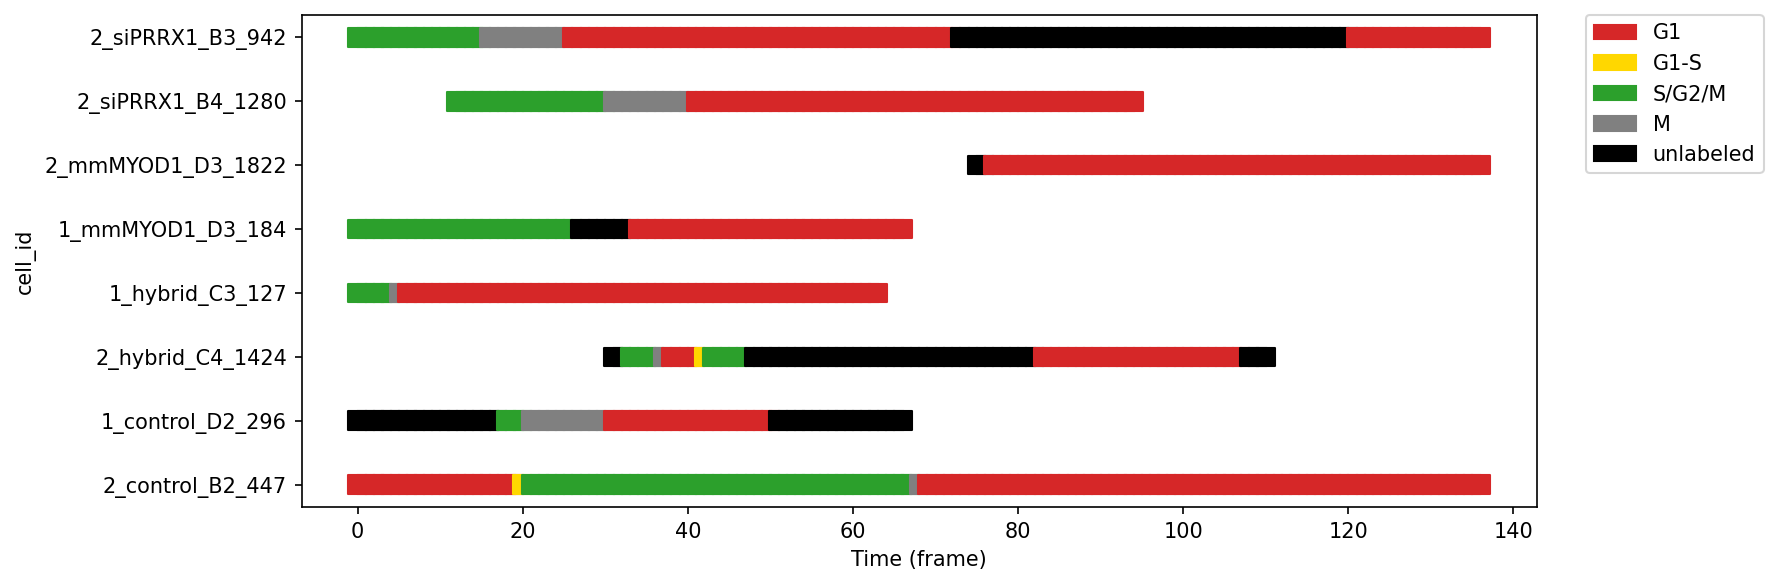

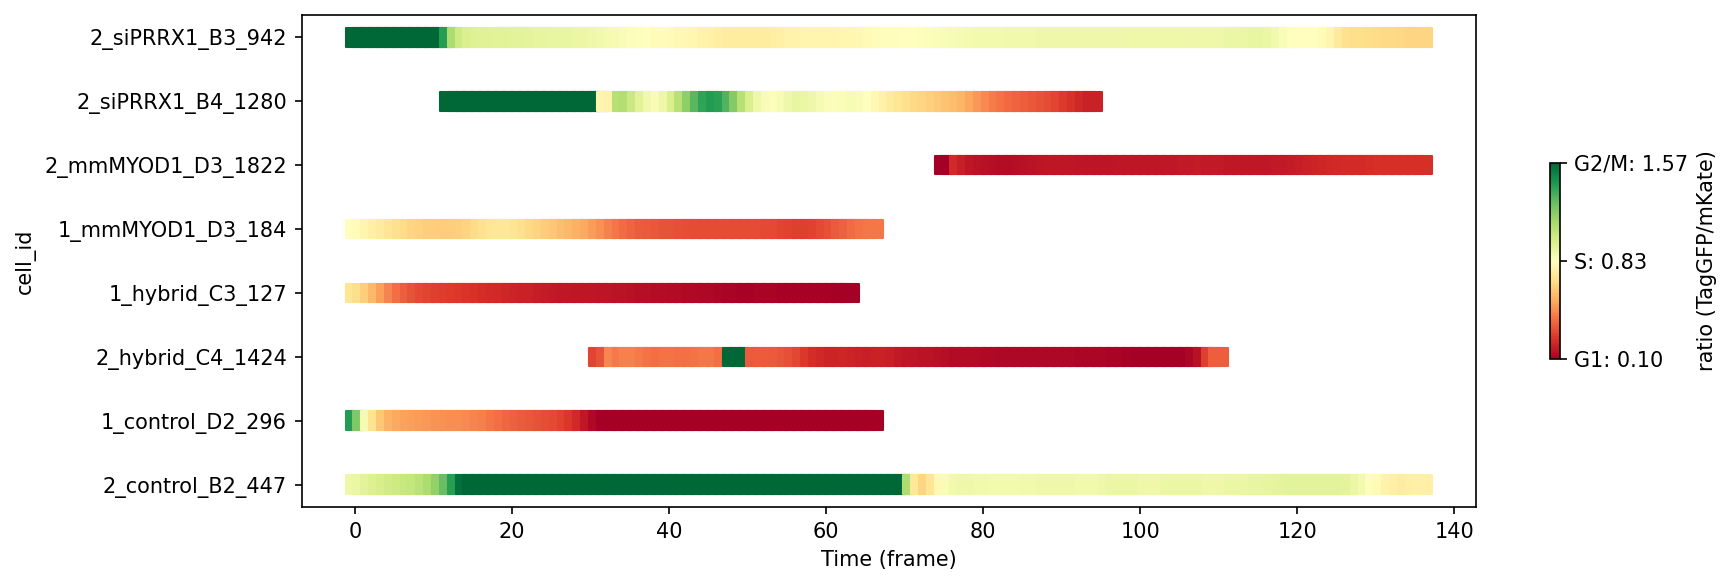

In [33]:
# sampled_cells = np.random.choice(df_phases['particle_id'].unique(), size=6, replace=False)

sampled_cells = (
    not_flat.groupby('condition')['particle_id']
    .apply(lambda x: np.random.choice(x.unique(), size=min(2, len(x)), replace=False))
    .explode()
    .tolist()
)

# Phase assignments
phase_colors = {
    'G1': 'tab:red',
    'G1-S': 'gold',
    'S/G2/M': 'tab:green',
    'M': 'gray',
    'unlabeled': 'black',
}
phase_order = ['G1', 'G1-S', 'S/G2/M', 'M', 'unlabeled']

fig, ax = plt.subplots(figsize=(12, 4))

for i, cell_id in enumerate(sampled_cells):
    cdf = df_phases[df_phases['particle_id'] == cell_id].sort_values('frame')
    colors = cdf['phase_final2'].map(phase_colors)
    ax.scatter(
        cdf['frame'],
        np.full_like(cdf['frame'], i, dtype=float),
        c=colors,
        s=80,
        marker='s',
    )

ax.set_yticks(range(len(sampled_cells)))
ax.set_yticklabels(sampled_cells)
ax.set_xlabel('Time (frame)')
ax.set_ylabel('cell_id')

legend_patches = [Patch(color=phase_colors[ph], label=ph) for ph in phase_order]
ax.legend(handles=legend_patches, bbox_to_anchor=(1.04, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

# Ratios for same cells
cmap = plt.get_cmap('RdYlGn')
vmin = df_phases['ratio_smooth'].quantile(0.1)
vmax = df_phases['ratio_smooth'].quantile(0.9)
vmid = 0.5 * (vmin + vmax)

labels = [
    f"G1: {vmin:.2f}",
    f"S: {vmid:.2f}",
    f"G2/M: {vmax:.2f}",
]

fig, ax = plt.subplots(figsize=(12, 4))

for i, cell_id in enumerate(sampled_cells):
    cdf = df_phases[df_phases['particle_id'] == cell_id].sort_values('frame')
    ax.scatter(
        cdf['frame'],
        np.full_like(cdf['frame'], i, dtype=float),  # y-position: cell number
        c=cdf['ratio_smooth'],
        s=80,
        marker='s',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        # edgecolor='k'
    )

ax.set_yticks(range(len(sampled_cells)))
ax.set_yticklabels(sampled_cells)
ax.set_xlabel('Time (frame)')
ax.set_ylabel('cell_id')

# Step 5: Add Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar = fig.colorbar(
    sm,
    ax=ax,
    label='ratio (TagGFP/mKate)',
    shrink=0.4,
    ticks=[vmin, vmid, vmax],
)
cbar.ax.set_yticklabels(labels)

plt.tight_layout()
plt.show()

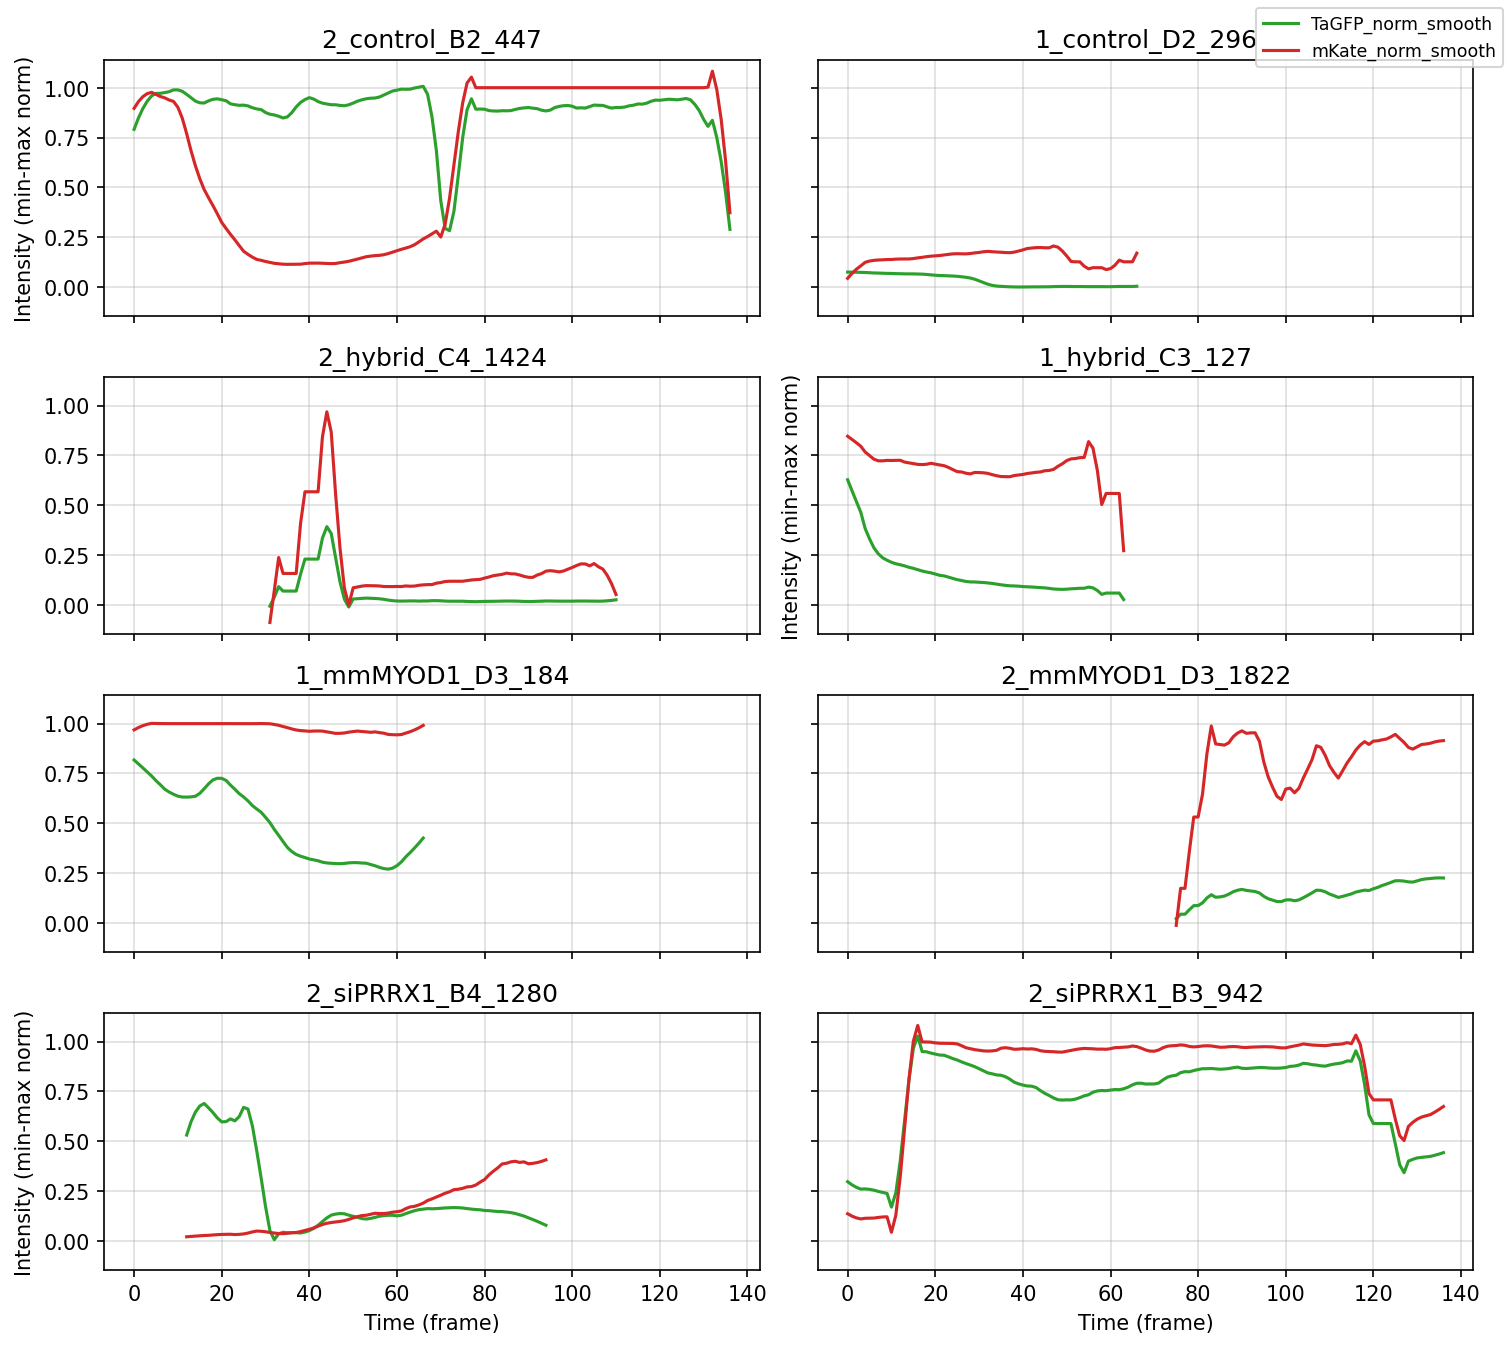

In [34]:
fig, axes = plt.subplots(4, 2, figsize=(10, 9), sharex=True, sharey=True)
axes = axes.flatten()
for idx, cell_id in enumerate(sampled_cells):
    ax = axes[idx]
    cdf = df_phases[df_phases['particle_id'] == cell_id].sort_values('frame')
    
    ax.plot(cdf['frame'], cdf['TaGFP_norm_smooth'], label='TaGFP_norm_smooth', color='tab:green')
    ax.plot(cdf['frame'], cdf['mKate_norm_smooth'], label='mKate_norm_smooth', color='tab:red')
    
    ax.set_title(f'{cell_id}')
    ax.grid(True, alpha=0.4)
    ax.set_xlabel('Time (frame)' if idx // n_cols == n_rows - 1 else '')
    ax.set_ylabel('Intensity (min-max norm)' if idx % n_cols == 0 else '')

for ax in axes[len(noisy_cells):]:
    ax.set_visible(False)
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

# High-confidence phase calls

In [24]:
def get_confidence_metrics(df_cell):
    """Calculates confidence metrics for a single cell trace."""
    n_frames = len(df_cell)
    
    # 1. Length and Completeness
    unlabeled_count = (df_cell['phase_final2'] == 'unlabeled').sum()
    unlabeled_prop = unlabeled_count / n_frames if n_frames > 0 else 1.0
    
    # 2. Progression
    has_g1s = ('G1-S' in df_cell['phase_final2'].values)
    has_m = ('M' in df_cell['phase_final2'].values)
    
    # 3. Jitter (Counting distinct phase blocks)
    # Count of times phase changes
    n_switches = (df_cell['phase_final2'] != df_cell['phase_final2'].shift(1)).sum() - 1 
    
    # 4. Phase proportions
    phase_counts = df_cell['phase_final2'].value_counts(normalize=True).to_dict()
    
    return pd.Series({
        'n_frames': n_frames,
        'unlabeled_prop': unlabeled_prop,
        'has_transition': has_g1s or has_m,
        'has_g1s': has_g1s,
        'has_m': has_m,
        'n_switches': n_switches,
        'prop_g1': phase_counts.get('G1', 0),
        'prop_sg2m': phase_counts.get('S/G2/M', 0),
    })

df_metrics = df_phases.groupby('particle_id').apply(get_confidence_metrics, include_groups=False)

df_metrics.head()

,n_frames,unlabeled_prop,has_transition,has_g1s,has_m,n_switches,prop_g1,prop_sg2m
particle_id,,,,,,,,
1_control_B2_0,67,0.000000,False,False,False,0,1.000000,0.000000
1_control_B2_101,67,0.074627,True,True,False,3,0.776119,0.134328
1_control_B2_102,50,0.180000,False,False,False,2,0.680000,0.140000
1_control_B2_103,67,0.000000,False,False,False,0,1.000000,0.000000
1_control_B2_104,67,0.000000,True,False,True,2,0.835821,0.149254


In [25]:
print(df_metrics.shape)
print(df_metrics['has_transition'].value_counts())
print(df_metrics['has_g1s'].value_counts())
print(df_metrics['has_m'].value_counts())

df_metrics.describe()

(14249, 8)
has_transition
True     7864
False    6385
Name: count, dtype: int64
has_g1s
False    9671
True     4578
Name: count, dtype: int64
has_m
False    8715
True     5534
Name: count, dtype: int64


,n_frames,unlabeled_prop,n_switches,prop_g1,prop_sg2m
count,14249.000000,14249.000000,14249.000000,14249.000000,14249.000000
mean,87.835988,0.172700,1.998175,0.629956,0.131076
std,30.099304,0.322569,2.285183,0.344002,0.201242
min,50.000000,0.000000,0.000000,0.000000,0.000000
25%,67.000000,0.000000,0.000000,0.386861,0.000000
50%,67.000000,0.000000,2.000000,0.716418,0.000000
75%,117.000000,0.142857,3.000000,0.945455,0.208955
max,137.000000,1.000000,30.000000,1.000000,1.000000


In [26]:
MAX_UNLABELED_PROP = 0.05
MAX_SWITCHES = 10

confidence_filter = (
    (df_metrics['unlabeled_prop'] <= MAX_UNLABELED_PROP) &
    # (df_metrics['has_transition']) & # Must have 'G1-S' or 'M'
    (df_metrics['n_switches'] <= MAX_SWITCHES)
)

confident_ids = df_metrics[confidence_filter].index
df_confident = df_phases[df_phases['particle_id'].isin(confident_ids)]

print(df_confident['particle_id'].nunique())
df_confident.head()

9227


,frame,condition,scene,stage,particle,particle_id,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,ratio_smooth,flat_flag,phase_raw,phase_final,phase_smoothed,phase_final2,vmin,vmax,vmid,small_range
0,0,control,B2,1.0,0.0,1_control_B2_0,0.0,136.0,0.061765,0.408809,...,0.556557,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
1,1,control,B2,1.0,0.0,1_control_B2_0,1.0,143.0,0.149553,0.394926,...,0.551582,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
2,2,control,B2,1.0,0.0,1_control_B2_0,2.0,153.0,0.252953,0.375882,...,0.542279,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
3,3,control,B2,1.0,0.0,1_control_B2_0,3.0,156.0,0.374112,0.369431,...,0.534920,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN
4,4,control,B2,1.0,0.0,1_control_B2_0,4.0,158.0,0.486338,0.368193,...,0.530026,True,G1,G1,G1,G1,NaN,NaN,NaN,NaN


In [27]:
group_counts = df_confident.groupby(['condition', 'scene'])['particle_id'].nunique().reset_index(name='n_confident_cells')
display(group_counts)

,condition,scene,n_confident_cells
0,control,B2,875
1,control,C2,895
2,control,D2,654
3,hybrid,C3,777
4,hybrid,C4,904
5,hybrid,C6,1074
6,mmMYOD1,D3,632
7,mmMYOD1,D4,706
8,siPRRX1,B3,1320
9,siPRRX1,B4,1390


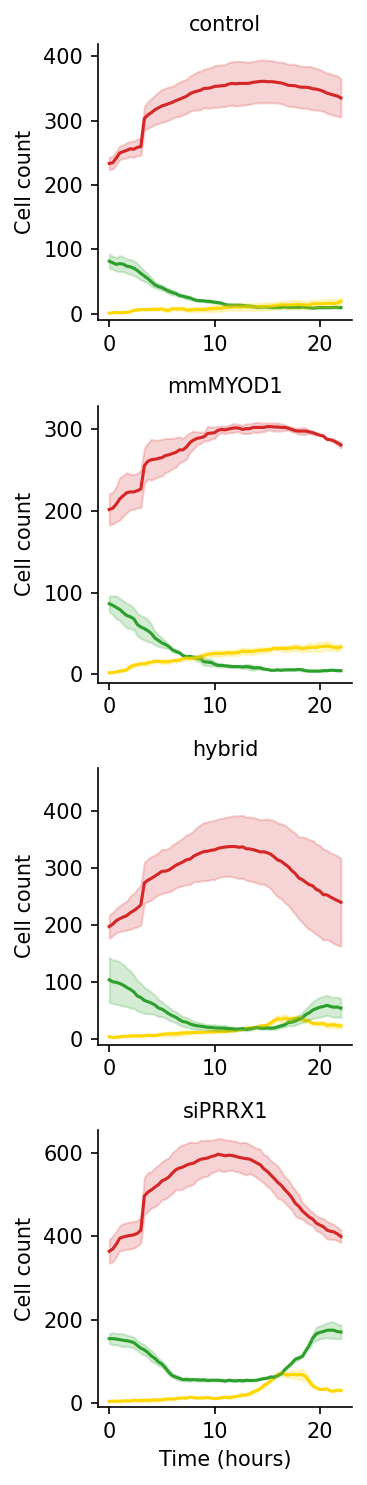

In [28]:
phase_counts = (
    df_confident
    .groupby(['frame', 'stage', 'condition', 'scene', 'phase_final2'])
    .size()
    .reset_index(name='n_cells')
)

# drop unlabeled
phase_counts = phase_counts[phase_counts['phase_final2'] != 'unlabeled']

# drop M phase for now
phase_counts = phase_counts[phase_counts['phase_final2'] != 'M']

# shift stage 2 times to follow after stage 1
max_time_stage1 = phase_counts.loc[phase_counts["stage"] == 1.0, "frame"].max()
phase_counts["time_shifted"] = phase_counts["frame"] + (
    (phase_counts["stage"] == 2.0) * (max_time_stage1 + 1)
)

# calculate hours (1 time point = 20 minutes)
phase_counts['time_hours'] = phase_counts['time_shifted'] / 3

max_cells_per_condition = (
    phase_counts
    .groupby('condition')['n_cells']
    .max()
    .to_dict()
)


stage = 1.0
phase_counts = phase_counts[phase_counts['stage'] == stage]


plt.rcParams['figure.dpi'] = 150
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(3, 10)) # 6x10 for stage 2, 3x10 for stage 1

conditions = ['control', 'mmMYOD1', 'hybrid', 'siPRRX1']

phase_colors = {
    'G1': 'tab:red',
    'G1-S': 'gold',
    'S/G2/M': 'tab:green',
    # 'M': 'gray',
    # 'unlabeled': 'black',
}

for ax, cond in zip(axes, conditions):
    d = phase_counts.loc[phase_counts["condition"] == cond]

    sns.lineplot(
        data=d,
        x="time_hours",
        y="n_cells",
        hue="phase_final2",
        ax=ax,
        palette=phase_colors,
        lw=1.5,
        errorbar='se',
        zorder=0,
    )

    ax.set_title(f"{cond}", fontsize=10)
    ax.set_ylabel("Cell count")
    ax.set_xlabel("")

    max_y = max_cells_per_condition[cond]
    ax.set_ylim(-10, max_y + 20)
    
    ax.legend().set_visible(False)

axes[-1].set_xlabel("Time (hours)")


sns.despine()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

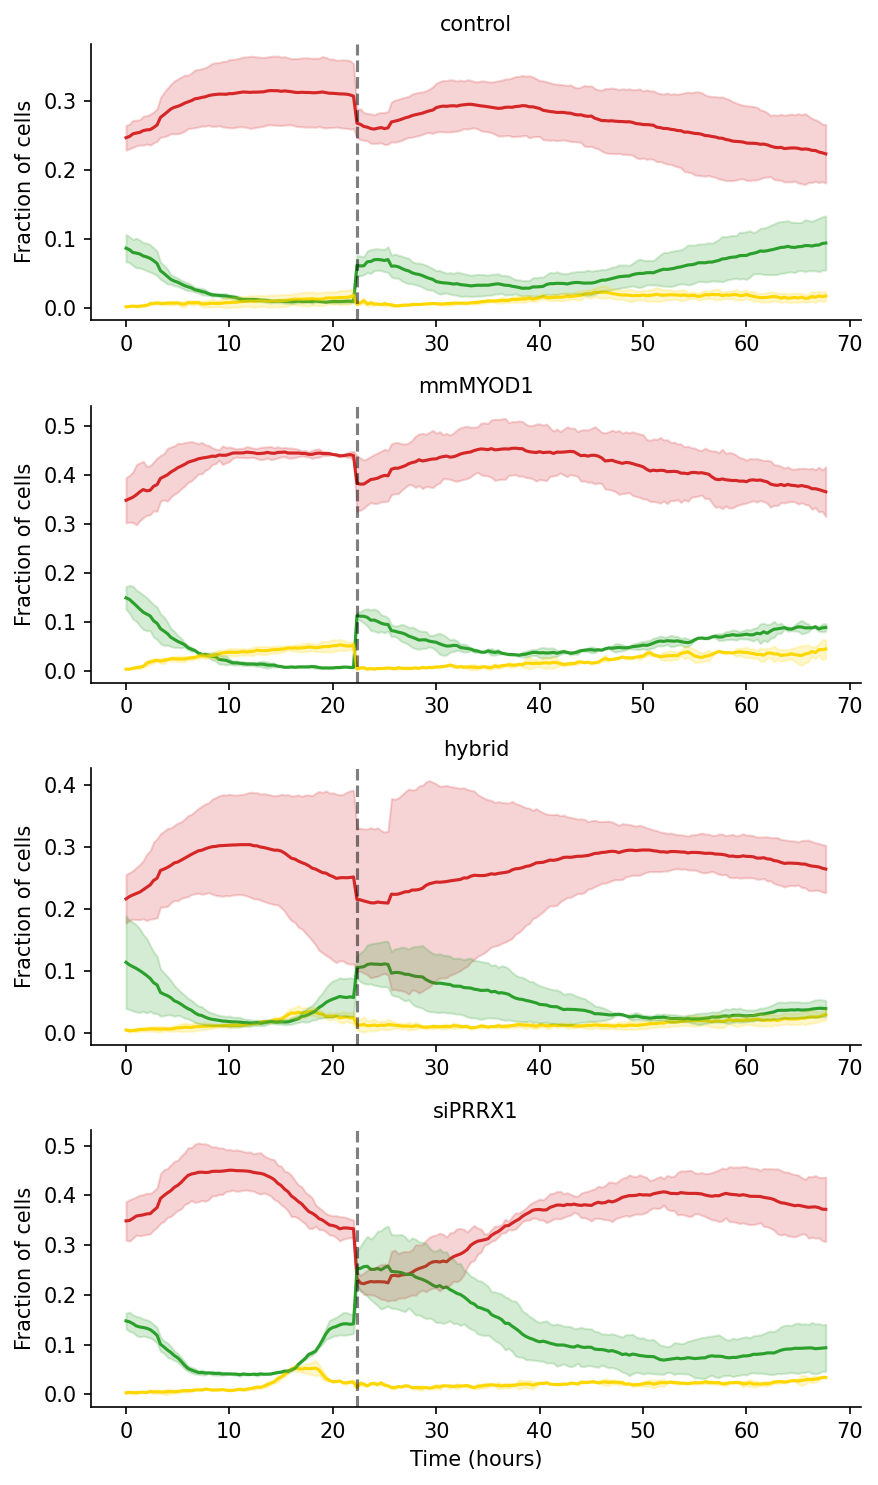

In [35]:
phase_counts = (
    df_confident
    .groupby(['frame', 'stage', 'condition', 'scene', 'phase_final2'])
    .size()
    .reset_index(name='n_cells')
)

# drop unlabeled
phase_counts = phase_counts[phase_counts['phase_final2'] != 'unlabeled']

# drop M phase for now
phase_counts = phase_counts[phase_counts['phase_final2'] != 'M']

# shift stage 2 times to follow after stage 1
max_time_stage1 = phase_counts.loc[phase_counts["stage"] == 1.0, "frame"].max()
phase_counts["time_shifted"] = phase_counts["frame"] + (
    (phase_counts["stage"] == 2.0) * (max_time_stage1 + 1)
)

# calculate hours (1 time point = 20 minutes)
phase_counts['time_hours'] = phase_counts['time_shifted'] / 3

max_cells_per_condition = (
    phase_counts
    .groupby('condition')['n_cells']
    .max()
    .to_dict()
)


# stage = 1.0
# phase_counts = phase_counts[phase_counts['stage'] == stage]



phase_counts['total_cells_timepoint'] = (
    phase_counts
    .groupby(['condition', 'time_shifted'])['n_cells']
    .transform('sum')
)

phase_counts['fraction'] = (
    phase_counts['n_cells'] / phase_counts['total_cells_timepoint']
)



plt.rcParams['figure.dpi'] = 150
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(7, 10)) # 6x10 for stage 2, 3x10 for stage 1

conditions = ['control', 'mmMYOD1', 'hybrid', 'siPRRX1']

phase_colors = {
    'G1': 'tab:red',
    'G1-S': 'gold',
    'S/G2/M': 'tab:green',
    # 'M': 'gray',
    # 'unlabeled': 'black',
}

for ax, cond in zip(axes, conditions):
    d = phase_counts.loc[phase_counts["condition"] == cond]

    sns.lineplot(
        data=d,
        x="time_hours",
        y="fraction",
        hue="phase_final2",
        ax=ax,
        palette=phase_colors,
        lw=1.5,
        errorbar='sd',
        zorder=0,
    )

    ax.set_title(f"{cond}", fontsize=10)
    ax.set_ylabel("Fraction of cells")
    ax.set_xlabel("")

    # max_y = max_cells_per_condition[cond]
    # ax.set_ylim(-10, max_y + 20)
    
    stage_boundary = (max_time_stage1 + 1) / 3

    ax.axvline(stage_boundary, linestyle='--', color='black', alpha=0.5)
    
    
    ax.legend().set_visible(False)

axes[-1].set_xlabel("Time (hours)")


sns.despine()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()